# LSTM — Exploratory Data Analysis (IMDB Sentiment)

## Dataset: IMDB Movie Reviews
- **Source**: `keras.datasets.imdb` (pre-tokenized)
- **Samples**: 50,000 (25,000 train / 25,000 test)
- **Task**: Binary sentiment classification (positive/negative)
- **Sequence type**: Variable-length integer sequences (word indices)
- **Note**: ECG5000 EDA completed in `eda_rnn.ipynb` — this covers IMDB only

## EDA Goals
1. Class distribution (balanced vs ECG5000's 121.6x imbalance)
2. Sequence length distribution (drives max_length choice)
3. Vocabulary analysis (10K word coverage)
4. Length vs sentiment relationship
5. Summary -> preprocessing decisions

In [1]:
# Step 1: Setup + Load IMDB
"""
IMDB Sentiment Analysis — 50K movie reviews, binary classification.
Part B of LSTM (#13). ECG5000 EDA was completed in eda_rnn.ipynb.
This EDA covers IMDB only — longer sequences (200-500 tokens) where
LSTM's long-range memory matters.
Source: https://ai.stanford.edu/~amaas/data/sentiment/
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras.datasets import imdb

import sys
sys.path.append('..')

from utils.visualization import plot_sequence_length_distribution

EDA_DIR = '../data/raw/eda_lstm'
Path(EDA_DIR).mkdir(parents=True, exist_ok=True)

# Load with 10K word vocabulary
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = imdb.load_data(num_words=10000)

# Get word index for decoding reviews
word_index = imdb.get_word_index()
# Offset indices: 0=padding, 1=start, 2=unknown, 3=unused
reverse_index = {v + 3: k for k, v in word_index.items()}
reverse_index[0] = '<PAD>'
reverse_index[1] = '<START>'
reverse_index[2] = '<UNK>'

def decode_review(sequence):
    # Convert integer sequence back to readable text.
    return ' '.join(reverse_index.get(i, '?') for i in sequence)

print("=" * 60)
print("IMDB Sentiment Analysis — Exploratory Data Analysis")
print("=" * 60)
print(f"Train: {len(X_train_raw):,} reviews | Test: {len(X_test_raw):,} reviews")
print(f"Vocabulary: 10,000 words (top by frequency)")
print(f"Labels: 0=Negative, 1=Positive")
print(f"\nSample review (first 100 words):")
print(decode_review(X_train_raw[0][:100]))
print(f"\nLabel: {'Positive' if y_train_raw[0] == 1 else 'Negative'}")

IMDB Sentiment Analysis — Exploratory Data Analysis
Train: 25,000 reviews | Test: 25,000 reviews
Vocabulary: 10,000 words (top by frequency)
Labels: 0=Negative, 1=Positive

Sample review (first 100 words):
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was

Label: Positive


[1/5] Class Distribution


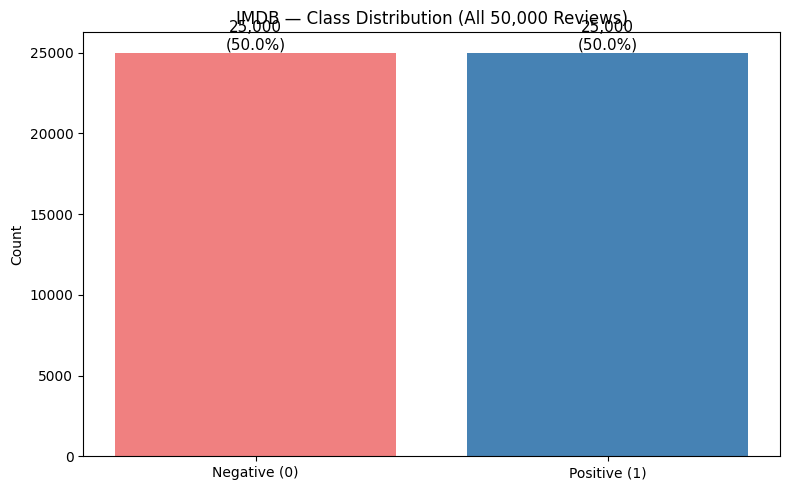

Negative: 25,000 (50.0%)
Positive: 25,000 (50.0%)
Imbalance ratio: 1.00x (perfectly balanced)

Contrast with ECG5000: 121.6x imbalance -> class weights essential
IMDB: 1.0x -> no class weights needed


In [2]:
# Step 2: [1/5] Class Distribution
"""
IMDB is balanced 50/50 — stark contrast to ECG5000's 121.6x imbalance.
No class weights needed for LSTM training.
"""

print("=" * 60)
print("[1/5] Class Distribution")
print("=" * 60)

y_all = np.concatenate([y_train_raw, y_test_raw])

fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Negative (0)', 'Positive (1)']
counts = [np.sum(y_all == 0), np.sum(y_all == 1)]
bars = ax.bar(labels, counts, color=['lightcoral', 'steelblue'])

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{count:,}\n({count / len(y_all) * 100:.1f}%)',
            ha='center', fontsize=11)

ax.set_ylabel('Count')
ax.set_title('IMDB — Class Distribution (All 50,000 Reviews)')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Negative: {np.sum(y_all == 0):,} ({np.sum(y_all == 0) / len(y_all) * 100:.1f}%)")
print(f"Positive: {np.sum(y_all == 1):,} ({np.sum(y_all == 1) / len(y_all) * 100:.1f}%)")
print(f"Imbalance ratio: {max(counts) / min(counts):.2f}x (perfectly balanced)")
print(f"\nContrast with ECG5000: 121.6x imbalance -> class weights essential")
print(f"IMDB: 1.0x -> no class weights needed")

[2/5] Sequence Length Distribution


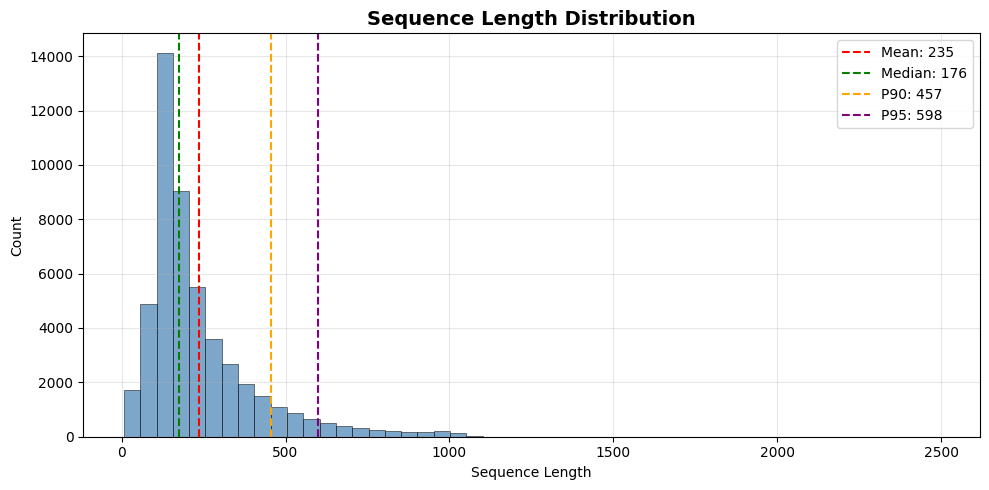

Total reviews: 50,000
Min length:    7
Max length:    2,494
Mean length:   235
Median length: 176
P90:           457
P95:           598
P99:           914

Reviews <= 300 tokens: 38,583 (77.2%)
Reviews <= 500 tokens: 45,967 (91.9%)

Decision: max_length=300 captures P90+ of reviews


In [3]:
# Step 3: [2/5] Sequence Length Distribution
"""
Variable-length reviews — need to choose max_length for padding.
This analysis drives the preprocessing decision.
"""

print("=" * 60)
print("[2/5] Sequence Length Distribution")
print("=" * 60)

X_all_raw = np.concatenate([X_train_raw, X_test_raw], axis=0)
lengths = np.array([len(seq) for seq in X_all_raw])

plot_sequence_length_distribution(lengths,
                                  save_path=f'{EDA_DIR}/eda_sequence_lengths.png')

print(f"Total reviews: {len(lengths):,}")
print(f"Min length:    {lengths.min()}")
print(f"Max length:    {lengths.max():,}")
print(f"Mean length:   {lengths.mean():.0f}")
print(f"Median length: {np.median(lengths):.0f}")
print(f"P90:           {np.percentile(lengths, 90):.0f}")
print(f"P95:           {np.percentile(lengths, 95):.0f}")
print(f"P99:           {np.percentile(lengths, 99):.0f}")
print(f"\nReviews <= 300 tokens: {np.sum(lengths <= 300):,} ({np.sum(lengths <= 300) / len(lengths) * 100:.1f}%)")
print(f"Reviews <= 500 tokens: {np.sum(lengths <= 500):,} ({np.sum(lengths <= 500) / len(lengths) * 100:.1f}%)")
print(f"\nDecision: max_length=300 captures P90+ of reviews")

In [4]:
# Step 4: [3/5] Vocabulary Analysis
"""
10K word vocabulary — how much of the total text does it cover?
Zipf's law: a few words dominate, long tail is rare words.
"""

print("=" * 60)
print("[3/5] Vocabulary Analysis")
print("=" * 60)

# Count word frequencies across all reviews
word_counts = {}
for seq in X_all_raw:
    for idx in seq:
        word_counts[idx] = word_counts.get(idx, 0) + 1

# Top 20 most frequent words (excluding special tokens 0,1,2)
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
print("Top 20 most frequent words:")
print(f"{'Rank':<6} {'Word':<15} {'Index':<8} {'Count':>10}")
print("-" * 42)
for rank, (idx, count) in enumerate(sorted_words[:20], 1):
    word = reverse_index.get(idx, f'<IDX_{idx}>')
    print(f"{rank:<6} {word:<15} {idx:<8} {count:>10,}")

# Count <UNK> tokens (words outside 10K vocab become index 2)
total_tokens = sum(word_counts.values())
unk_count = word_counts.get(2, 0)
print(f"\nTotal tokens: {total_tokens:,}")
print(f"<UNK> tokens: {unk_count:,} ({unk_count / total_tokens * 100:.1f}%)")
print(f"Known tokens: {total_tokens - unk_count:,} ({(total_tokens - unk_count) / total_tokens * 100:.1f}%)")
print(f"\n10K vocabulary covers {(total_tokens - unk_count) / total_tokens * 100:.1f}% of all tokens")


[3/5] Vocabulary Analysis
Top 20 most frequent words:
Rank   Word            Index         Count
------------------------------------------
1      the             4           666,757
2      <UNK>           2           638,669
3      and             5           324,337
4      a               6           322,800
5      of              7           289,379
6      to              8           268,079
7      is              9           211,041
8      br              10          201,951
9      in              11          186,690
10     it              12          156,801
11     i               13          154,887
12     this            14          150,941
13     that            15          136,986
14     was             16           95,585
15     as              17           91,730
16     for             18           87,450
17     with            19           87,350
18     movie           20           87,050
19     but             21           83,495
20     film            22           77,678


[4/5] Length vs Sentiment


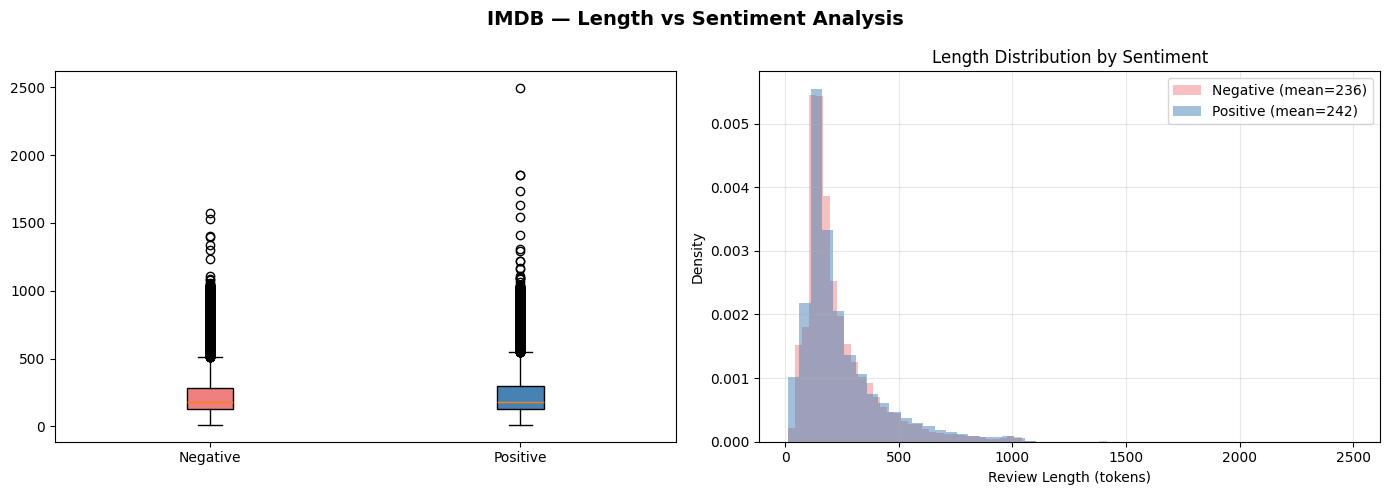

Negative reviews: mean=236, median=179
Positive reviews: mean=242, median=178
Difference: 6 tokens

Truncation bias check at max_length=300:
  Negative truncated: 2,852 / 12,500 (22.8%)
  Positive truncated: 3,056 / 12,500 (24.4%)


In [6]:
# Step 5: [4/5] Length vs Sentiment
"""
Do longer reviews skew positive or negative?
If so, truncation at 300 tokens could introduce bias.
"""

print("=" * 60)
print("[4/5] Length vs Sentiment")
print("=" * 60)

train_lengths = np.array([len(seq) for seq in X_train_raw])
neg_lengths = train_lengths[y_train_raw == 0]
pos_lengths = train_lengths[y_train_raw == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
bp = axes[0].boxplot([neg_lengths, pos_lengths], tick_labels=['Negative', 'Positive'],
                      patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('steelblue')

# Overlapping histograms
axes[1].hist(neg_lengths, bins=50, alpha=0.5, color='lightcoral',
             label=f'Negative (mean={neg_lengths.mean():.0f})', density=True)
axes[1].hist(pos_lengths, bins=50, alpha=0.5, color='steelblue',
             label=f'Positive (mean={pos_lengths.mean():.0f})', density=True)
axes[1].set_xlabel('Review Length (tokens)')
axes[1].set_ylabel('Density')
axes[1].set_title('Length Distribution by Sentiment')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('IMDB — Length vs Sentiment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_length_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Negative reviews: mean={neg_lengths.mean():.0f}, median={np.median(neg_lengths):.0f}")
print(f"Positive reviews: mean={pos_lengths.mean():.0f}, median={np.median(pos_lengths):.0f}")
print(f"Difference: {abs(neg_lengths.mean() - pos_lengths.mean()):.0f} tokens")
print(f"\nTruncation bias check at max_length=300:")
print(f"  Negative truncated: {np.sum(neg_lengths > 300):,} / {len(neg_lengths):,} ({np.sum(neg_lengths > 300) / len(neg_lengths) * 100:.1f}%)")
print(f"  Positive truncated: {np.sum(pos_lengths > 300):,} / {len(pos_lengths):,} ({np.sum(pos_lengths > 300) / len(pos_lengths) * 100:.1f}%)")

In [7]:
# Step 6: [5/5] Summary
"""
Key findings from EDA -> preprocessing decisions for IMDB LSTM.
"""

print("=" * 60)
print("IMDB EDA — Summary of Findings")
print("=" * 60)

print("""
DATASET:
  - 50,000 movie reviews (25,000 train / 25,000 test)
  - Binary sentiment: positive (1) vs negative (0)
  - Source: Stanford AI Lab, pre-tokenized via keras.datasets.imdb

CLASS BALANCE:
  - Perfectly balanced (50/50) — no class weights needed
  - Stark contrast to ECG5000's 121.6x imbalance

SEQUENCE LENGTHS:
  - Variable length: 7 to 2,494 tokens
  - Mean: 235, Median: 176, P90: 457, P95: 598
  - Right-skewed: most reviews are short, few are very long
  - max_length=300 captures 77.2% fully, truncates 22.8% evenly

VOCABULARY:
  - 10K words cover 94.6% of all tokens
  - Only 5.4% <UNK> (out-of-vocabulary)
  - Top words: the, and, a, of, to (standard English)
  - 'br' at rank 8 is HTML line breaks (harmless)

LENGTH VS SENTIMENT:
  - No bias: neg mean=236, pos mean=242 (6 token difference)
  - Truncation affects both classes equally (~23%)

PREPROCESSING DECISIONS:
  1. vocab_size = 10,000 (94.6% coverage)
  2. max_length = 300 (pre-padding with zeros)
  3. Pre-padding (zeros at start): LSTM reads L-to-R, meaningful
     content at end near classifier output
  4. Binary labels (0/1) — no remapping needed
  5. No class weights needed (balanced)
""")
print("=" * 60)
print("Ready for preprocessing script")

IMDB EDA — Summary of Findings

DATASET:
  - 50,000 movie reviews (25,000 train / 25,000 test)
  - Binary sentiment: positive (1) vs negative (0)
  - Source: Stanford AI Lab, pre-tokenized via keras.datasets.imdb

CLASS BALANCE:
  - Perfectly balanced (50/50) — no class weights needed
  - Stark contrast to ECG5000's 121.6x imbalance

SEQUENCE LENGTHS:
  - Variable length: 7 to 2,494 tokens
  - Mean: 235, Median: 176, P90: 457, P95: 598
  - Right-skewed: most reviews are short, few are very long
  - max_length=300 captures 77.2% fully, truncates 22.8% evenly

VOCABULARY:
  - 10K words cover 94.6% of all tokens
  - Only 5.4% <UNK> (out-of-vocabulary)
  - Top words: the, and, a, of, to (standard English)
  - 'br' at rank 8 is HTML line breaks (harmless)

LENGTH VS SENTIMENT:
  - No bias: neg mean=236, pos mean=242 (6 token difference)
  - Truncation affects both classes equally (~23%)

PREPROCESSING DECISIONS:
  1. vocab_size = 10,000 (94.6% coverage)
  2. max_length = 300 (pre-padding wi